# Resonance of a series RLC resonant circuit

## Sampling and Oscillatory Signals

When working with oscillatory systems numerically, it is important to sample the solution with sufficient resolution. If the sampling is too coarse compared to the oscillation frequency, the resulting plot can misrepresent the true behaviour of the system.

As an example, consider the function

$$
\cos(30x)e^{-x/4}
$$

which oscillates with period

$$
T = \frac{2\pi}{30} \approx 0.209
$$

If the function is sampled with many points per period, the oscillations are captured accurately:

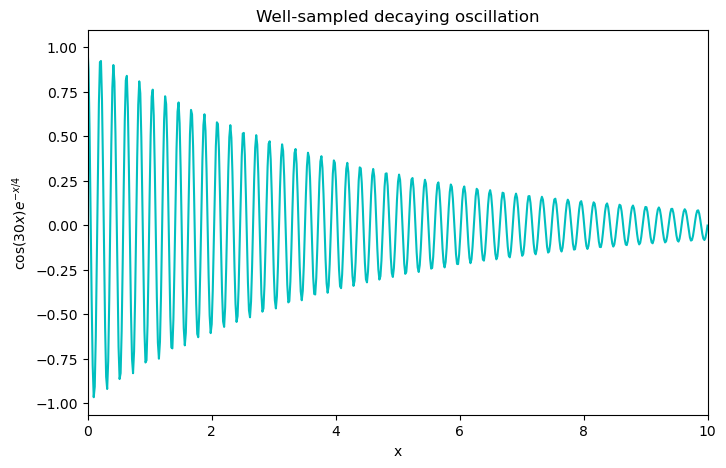

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# Create a finely sampled x-array
x = np.linspace(0, 10, 600)

# Define the decaying oscillatory function
y = np.cos(30 * x) * np.exp(-x / 4)

# Plot the well-sampled function
plt.figure(figsize = (8, 5))
plt.plot(x, y, 'c-')

plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel(r"$\cos(30x)e^{-x/4}$")
plt.title("Well-sampled decaying oscillation")

plt.show()

However, if the sampling interval becomes comparable to the oscillation period, the plotted result can exhibit artificial patterns that are not present in the true function:

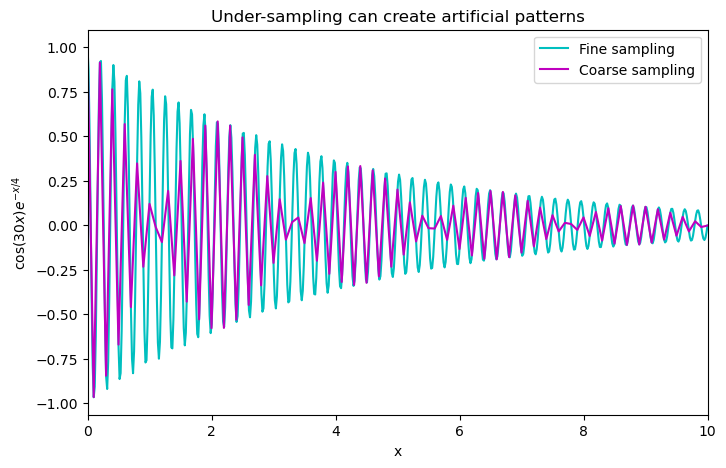

In [14]:
# Fine sampling
x_fine = np.linspace(0, 10, 600)
y_fine = np.cos(30 * x_fine) * np.exp(-x_fine / 4)

# Coarser sampling over a wider interval
x_coarse = np.linspace(0, 30, 301)
y_coarse = np.cos(30 * x_coarse) * np.exp(-x_coarse / 4)

# Compare fine and coarse sampling
plt.figure(figsize = (8, 5))

plt.plot(x_fine, y_fine, 'c-', label = "Fine sampling")
plt.plot(x_coarse, y_coarse, "m-", label = "Coarse sampling")

plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel(r"$\cos(30x)e^{-x/4}$")
plt.title("Under-sampling can create artificial patterns")

plt.legend()
plt.show()

This effect is known as **aliasing**. It occurs when a high-frequency signal is under-sampled, causing it to appear as a lower-frequency oscillation.

A useful guideline is provided by the **Nyquist criterion**, which states that the sampling frequency must be at least twice the highest frequency present in the signal in order to resolve it correctly.

This issue is particularly important when solving differential equations for oscillatory systems, such as the driven RLC circuit considered below.

## The Series RLC Circuit

We now consider a driven series RLC circuit consisting of a resistor $R$, inductor $L$, and capacitor $C$. The charge $q(t)$ on the capacitor satisfies the differential equation

$$
L\frac{d^2 q}{dt^2} + R\frac{dq}{dt} + \frac{1}{C}q = V_0 \cos(\omega t)
$$

Here:
- $q(t)$ is the charge on the capacitor
- $I(t) = \displaystyle \frac{dq}{dt}$ is the current
- $V_0$ is the amplitude of the driving voltage
- $\omega$ is the driving angular frequency

This equation describes a driven, damped oscillator. The three terms correspond to:
- inertia-like behaviour from the inductor
- energy dissipation due to resistance
- restoring force from the capacitor

## First-Order Formulation

To solve this equation numerically, we rewrite it as a system of first-order equations:

$$
\frac{dq}{dt} = I,
$$

$$
\frac{dI}{dt} = \frac{V_0}{L}\cos(\omega t) - \frac{R}{L}I - \frac{1}{LC}q
$$

This system can be solved using numerical methods such as `solve_ivp()`.

## Choice of Parameters

To explore a range of behaviours, we select values of $L$ and $C$ spanning several orders of magnitude. From these, we define three resistance values:

- an **underdamped** case $(R < 2\sqrt{L/C})$
- a **critically damped** case $(R = 2\sqrt{L/C})$
- an **overdamped** case $(R > 2\sqrt{L/C})$

The natural angular frequency of the circuit is

$$
\omega_0 = \frac{1}{\sqrt{LC}}
$$

We will first examine the time evolution of the current when the system is driven at this frequency.

In [15]:
# Generate inductance and capacitance values spanning several orders of magnitude
# so that the behaviour of the circuit can be explored for different physical regimes
def generate_lc_values():
    a_L = np.random.randint(10, 100) # generates a two-digit integer between 10 and 99
    b_L = np.random.randint(-9, -4) # generates an integer between -9 and -5
    L = a_L * 10**b_L # Inductance in Henries (H)

    a_C = np.random.randint(10, 100)
    b_C = np.random.randint(-9, -4)
    C = a_C * 10**b_C # Capacitance in Farads (F)

    return L, C


# Generate L and C
L, C = generate_lc_values()

# Driving voltage amplitude
V0 = 0.1

# Natural angular frequency
omega0 = 1 / np.sqrt(L * C)

# Critical resistance (in Ohms) for the RLC circuit
R_crit = 2 * np.sqrt(L / C)

# Three damping cases
R_under = 0.1 * R_crit
R_critical = R_crit
R_over = 5 * R_crit


# RLC system written as two first-order ODEs
# state = [q, I], where q is charge and I = dq/dt is current
def rlc_system(t, state, R, omega):
    q, I = state

    dqdt = I
    dIdt = (V0 / L) * np.cos(omega * t) - (R / L) * I - (1 / (L * C)) * q

    return [dqdt, dIdt]


# Print parameter values
print(f"L = {L:.3e} H")
print(f"C = {C:.3e} F")
print(f"omega0 = {omega0:.3e} rad/s")
print(f"R_under = {R_under:.3e} ohms")
print(f"R_critical = {R_critical:.3e} ohms")
print(f"R_over = {R_over:.3e} ohms")

L = 1.600e-05 H
C = 7.700e-05 F
omega0 = 2.849e+04 rad/s
R_under = 9.117e-02 ohms
R_critical = 9.117e-01 ohms
R_over = 4.558e+00 ohms


## Time Evolution of the Current

We solve the system numerically for the three damping cases, starting from the initial conditions

$$
q(0) = 0, \qquad I(0) = 0
$$

The driving voltage is taken to be

$$
V(t) = V_0 \cos(\omega_0 t)
$$

so that the system is driven at its natural frequency.

The resulting plots show how the current evolves from an initial transient state into a steady oscillation. The rate at which this occurs depends strongly on the level of damping.

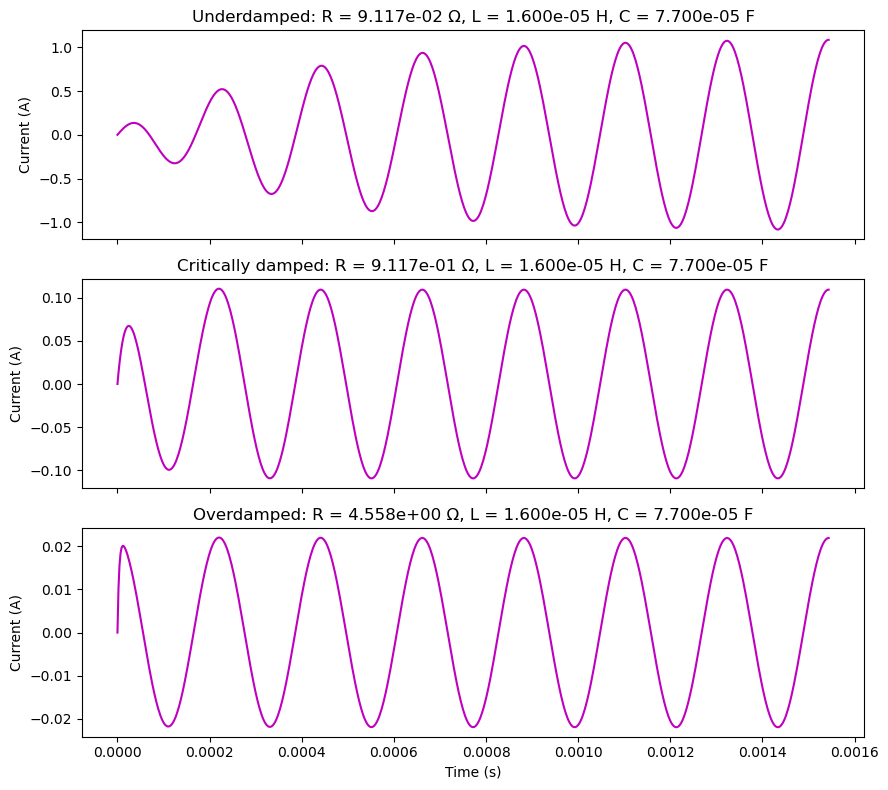

In [16]:
# Solve the driven RLC circuit for a given resistance and driving frequency
def solve_rlc(R, omega, periods=7, points_per_period = 100):
    # Period of the driving voltage
    T = 2 * np.pi / omega

    # Use several periods to capture the transient and steady-state behaviour
    t_max = periods * T

    # Choose enough time points to resolve the oscillation
    t_eval = np.linspace(0, t_max, periods * points_per_period + 1)

    # Initial conditions: no charge and no current
    initial_state = [0, 0]

    # Solve the ODE system
    sol = solve_ivp(
        rlc_system,
        (0, t_max),
        initial_state,
        t_eval = t_eval,
        args = (R, omega),
        method = "LSODA"
    )

    # Extract time and current
    t = sol.t
    I = sol.y[1]

    return t, I


# Solve the three damping cases at the natural frequency
t_under, I_under = solve_rlc(R_under, omega0)
t_critical, I_critical = solve_rlc(R_critical, omega0)
t_over, I_over = solve_rlc(R_over, omega0)


# Plot the three current responses
fig, axes = plt.subplots(3, 1, figsize = (9, 8), sharex = True)

cases = [
    (t_under, I_under, R_under, "Underdamped"),
    (t_critical, I_critical, R_critical, "Critically damped"),
    (t_over, I_over, R_over, "Overdamped"),
]

for ax, (t, I, R, label) in zip(axes, cases):
    ax.plot(t, I, 'm-')

    ax.set_ylabel("Current (A)")
    ax.set_title(f"{label}: R = {R:.3e} Ω, L = {L:.3e} H, C = {C:.3e} F")

axes[-1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

## Resonance

We now investigate how the steady-state amplitude of the current depends on the driving frequency.

For each value of the frequency $\omega$, the system is solved numerically, and the amplitude of the steady-state oscillation is extracted after the transient behaviour has decayed.

The resulting curves show the phenomenon of **resonance**, where the response of the system is maximized when the driving frequency is close to the natural frequency.

The shape of the resonance curve depends on the damping:
- the underdamped system exhibits a sharp peak
- the critically damped system shows a broader maximum
- the overdamped system responds more weakly and without a pronounced peak

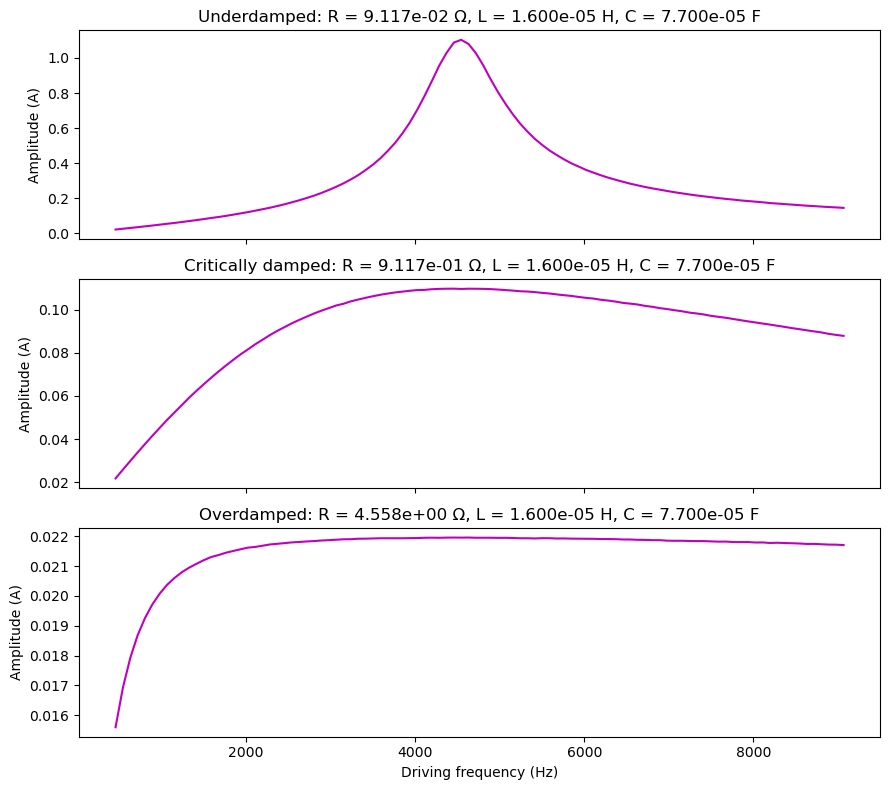

In [17]:
# Estimate the steady-state current amplitude
def steady_state_amplitude(R, omega):
    # Use more periods here so the transient has time to decay
    t, I = solve_rlc(R, omega, periods = 20, points_per_period = 100)

    # Use only the final quarter of the signal to estimate steady-state amplitude
    start_index = int(0.75 * len(I))
    I_steady = I[start_index:]

    # Amplitude is half the peak-to-peak value
    amplitude = 0.5 * (np.max(I_steady) - np.min(I_steady))

    return amplitude


# Driving angular frequencies to test
omega_values = np.linspace(0.1 * omega0, 2 * omega0, 100)

# Convert angular frequency to ordinary frequency in Hz
frequency_values = omega_values / (2 * np.pi)


# Compute resonance curves for the three damping cases
amplitude_under = np.array([
    steady_state_amplitude(R_under, omega)
    for omega in omega_values
])

amplitude_critical = np.array([
    steady_state_amplitude(R_critical, omega)
    for omega in omega_values
])

amplitude_over = np.array([
    steady_state_amplitude(R_over, omega)
    for omega in omega_values
])

# Plot current amplitude vs driving frequency
fig, axes = plt.subplots(3, 1, figsize = (9, 8), sharex = True)

resonance_cases = [
    (amplitude_under, R_under, "Underdamped"),
    (amplitude_critical, R_critical, "Critically damped"),
    (amplitude_over, R_over, "Overdamped"),
]

for ax, (amplitude, R, label) in zip(axes, resonance_cases):
    ax.plot(frequency_values, amplitude, 'm-')

    ax.set_ylabel("Amplitude (A)")
    ax.set_title(f"{label}: R = {R:.3e} Ω, L = {L:.3e} H, C = {C:.3e} F")

axes[-1].set_xlabel("Driving frequency (Hz)")

plt.tight_layout()
plt.show()